In [2]:
import scanpy as sc

In [3]:
rdata = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/cd8tcells_extra_genes.h5ad')

/tmp/ipykernel_273833/2179754416.py:1: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  rdata = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/cd8tcells_extra_genes.h5ad')


In [4]:
# Ensure the column is a 'category' type
rdata.obs['sample'] = rdata.obs['condition'].str.rstrip('_').astype('category')
rdata.obs['sample'] = rdata.obs['sample'].astype('category')

# Reorder the categories in the 'sample' column
rdata.obs['sample_old'] = rdata.obs['sample'].copy()
new_order_sp = ['naive_d4', 'activated_d1', 'exhausted_d3', 'exhausted_d4']
rdata.obs['sample'] = rdata.obs['sample'].cat.set_categories(new_order_sp, ordered=True)

# Create color dictionaryvar
color_dict_sp = {
    "naive_d4": "#7BAFDE",  # blue
    "activated_d1": "#96C793",  # green
    "exhausted_d3": "#D78184",  # red
    "exhausted_d4": "#b00409"   # dark red
}

# Map the dictionary to the category order
rdata.uns['sample_colors'] = [color_dict_sp[cat] for cat in rdata.obs['sample'].cat.categories]

# Plot to verify
# Replace 'old_name_1', 'old_name_2', etc., with your actual existing category names
category_map = {
    "naive_d4": "Naive",
    "activated_d1": "Activated",
    "exhausted_d3": "Exhausted (D3)",
    "exhausted_d4": "Exhausted (D4)"
}

# Update categories directly
rdata.obs["sample"] = (
    rdata.obs["sample"]
    .astype("category")
    .cat.rename_categories(category_map)
)



In [5]:
gene_signatures = {
    #"exhaustion": ['Pdcd1', 'Lag3', 'Havcr2', 'Tigit', 'Ctla4', 'Tox', 'Eomes', 'Nr4a1', 'Nr4a2', 'Nr4a3', 'Batf', 'Irf4', 'Nfatc1', 'Nfatc2', 'Maf', 'Bhlhe40', 'Bhlhe41', 'Bach1', 'Bach2', 'Cd200r1', 'Cxcr3', 'Dusp4', 'Ikzf2', 'Hells','Mt1', 'Mt2', 'Myb', 'Pbx3', 'Rgs16', 'Tigit', 'Tnfrsf9', 'Xcl1'],
    "exhaustion": ['Pdcd1', 'Lag3', 'Havcr2', 'Tigit', 'Tox', 'Eomes', 'Maf', 'Bach1', 'Cd200r1', 'Ikzf2', 'Tigit'],
    "activation": ['Fasl', 'Ccl3', 'Ccl4', 'Ccl5','Gzma','Gzmb', 'Gzmc', 'Gzmk', 'Gzmm', 'Ifng', 'Prf1', 'Ctsd', 'Ctsw', 'Tnf', 'Nkg7', 'Klrg1', 'Cd40lg', 'Tgfb1', 'Tgfb2', 'Tgfb3', 'Csf1', 'Csf2', 'Lif', 'Osm', 'Lta', 'Cd69', 'Il2ra', 'Cd44', 'Prdm1', 'Tbx21', 'Tnfrsf9', 'Nfatc1', 'Nfatc2'],
    "naive": ['Sell', 'Ccr7', 'Tcf7', 'Lef1', 'Il7r', 'Slamf6','Klf2','Klf3']
}

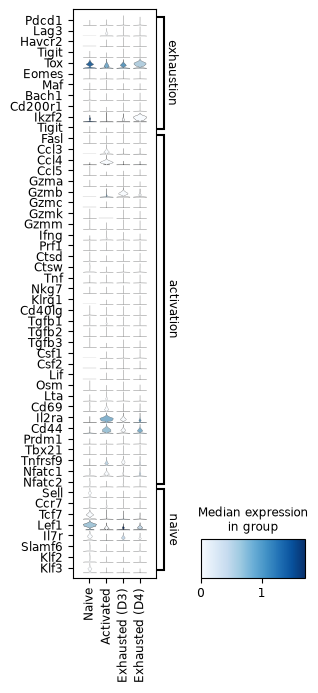

In [11]:

plo =sc.pl.stacked_violin(rdata, gene_signatures, groupby='sample', swap_axes=True, dodge=False, figsize=(3, 7), return_fig=True)
plo.savefig('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/violin_plot_marker_genes.pdf', bbox_inches='tight')
